In [5]:
import torch
torch.manual_seed(101)

## 1. Embedding层

In [8]:
vocab_size = 10
emb_size = 4

In [5]:
emb_layer = torch.nn.Embedding(num_embeddings=vocab_size, embedding_dim=emb_size)
print(emb_layer.weight)

Parameter containing:
tensor([[-0.6028, -0.1208, -0.4323,  1.8811],
        [-0.7158,  0.0026,  0.2056,  0.5626],
        [ 0.2795, -1.0873,  0.0613,  0.9088],
        [-0.4134, -0.1937, -2.1826,  0.7185],
        [-1.4568, -0.9884,  1.0552,  0.7783],
        [ 1.0674,  0.1143, -0.5580,  0.3066],
        [ 0.7036, -1.7144, -1.2538, -0.2323],
        [-0.2584, -1.3357,  0.4019,  1.2692],
        [-0.8117,  0.7122, -0.3675,  1.5508],
        [ 0.9977,  1.4884,  0.7323,  0.6127]], requires_grad=True)


In [6]:
print(emb_layer(torch.tensor([2, 1, 3])))

tensor([[ 0.2795, -1.0873,  0.0613,  0.9088],
        [-0.7158,  0.0026,  0.2056,  0.5626],
        [-0.4134, -0.1937, -2.1826,  0.7185]], grad_fn=<EmbeddingBackward0>)


## 2. 位置编码Positional Encoding
由于自注意力机制无法感知词元在序列中的位置，因此需要引入位置编码。位置编码是一个固定长度的向量，用于表示词元在序列中的位置。
- 绝对位置编码：给每个位置一个固定编号，只表示 “在第几个位置”。
  - 代表：Transformer 原版的 sin/cos 位置编码、可学习位置编码。
  - 优势：简单、直接，不需要模型学习位置关系。
  - 劣势：无法处理长序列，因为位置编码是固定的，无法表示序列中的长距离关系。
- 相对位置编码：只关心两个位置之间的距离 / 关系，不关心具体在哪。
  - 代表：Transformer-XL、T5、RoPE、ALiBi等。
  - 优势：可以处理长序列，因为位置编码是根据相对距离计算得到的，不依赖于绝对位置。

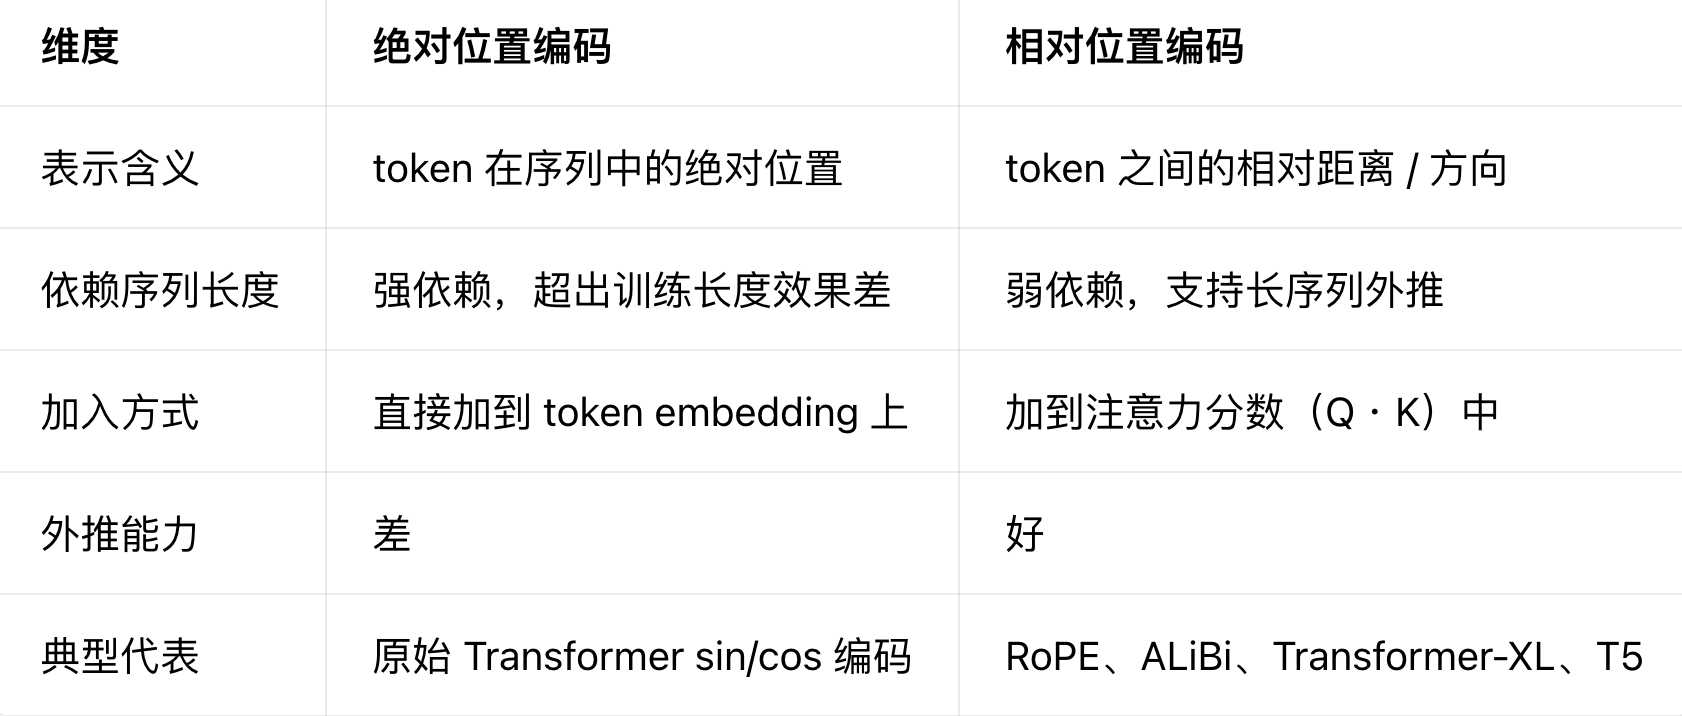

In [10]:
context_length = 10
pos_embedding_layer = torch.nn.Embedding(context_length, emb_size)
pos_embeddings = pos_embedding_layer(torch.arange(context_length))
print(pos_embeddings)

tensor([[ 0.2436, -2.4954, -1.5642,  0.7871],
        [ 1.5733, -1.1225,  1.8410, -0.4351],
        [ 0.4267, -0.1585,  0.5144,  0.0149],
        [-0.6640,  0.5721, -0.3550,  0.4554],
        [ 0.7637,  1.7607, -0.6025,  0.8273],
        [-1.4695, -1.2534,  0.5590,  0.3541],
        [ 0.9773,  0.4292, -0.8906, -0.0823],
        [-0.0120, -0.1540,  0.5874, -0.6361],
        [ 0.8039, -1.6214,  1.6751,  0.1186],
        [ 0.7646, -1.0890, -1.0525, -1.2369]], grad_fn=<EmbeddingBackward0>)
